In [1]:
import os
import json

import numpy as np
from matplotlib import pyplot as plt

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


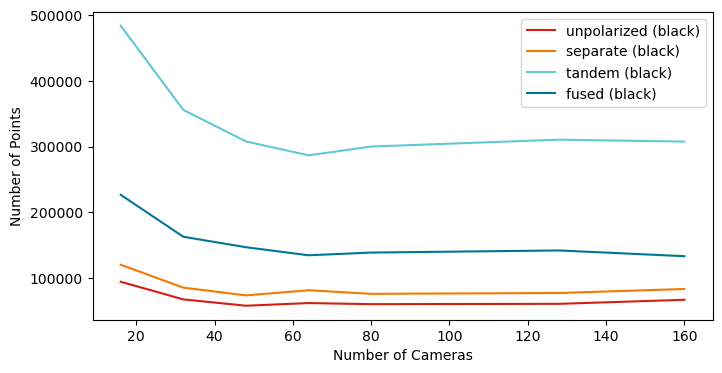

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


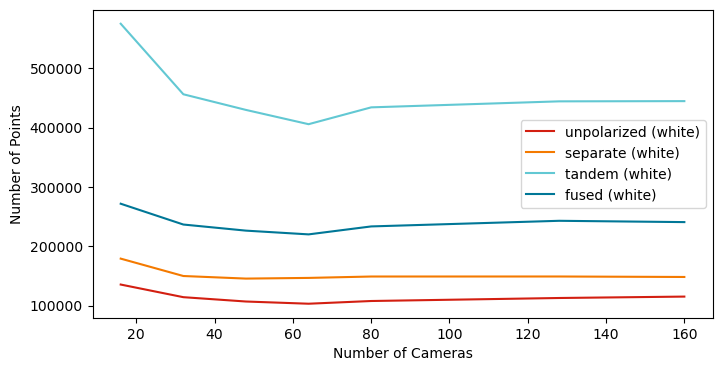

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


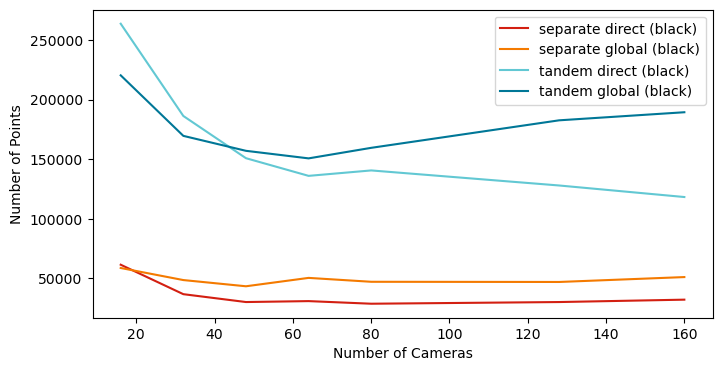

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


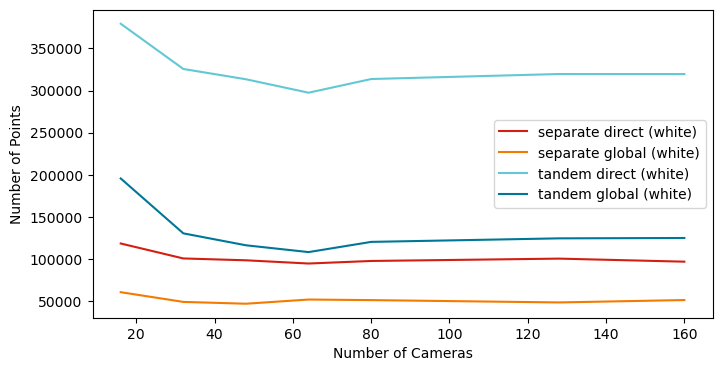

In [3]:
output_path = "../../../output"

def point_count(method, scene, bg, cam_num, file_name="train_results.json"):
	bg_string = "" if bg == "black" else "_white"

	path = os.path.join(output_path, f"{method}_{cam_num}{bg_string}", scene, "model", file_name)

	with open(path, "r") as f:
		data = json.load(f)
		return data["points"][-1]
	
def calc_point_count(method, bg, cam_num):
	if method == "unpolarized":
		return point_count("separate", "unpolarized", bg, cam_num)
	elif method == "fused":
		return point_count("fused", "composite", bg, cam_num, "train_results_combined.json")
	
	direct_count = point_count(method, "direct", bg, cam_num)
	global_count = point_count(method, "global", bg, cam_num)
	return direct_count + global_count

cam_nums = [16, 32, 48, 64, 80, 128, 160]	
methods = ["unpolarized", "separate", "tandem", "fused"]
bgs = ["black", "white"]
colors = ["#d31f11", "#f47a00", "#62c8d3", "#007797"]

# for method in methods:
# 	for bg in bgs:
# 		counts = [str(calc_point_count(method, bg, cam_num)) for cam_num in cam_nums]
# 		counts_string = " & ".join(counts)
# 		print(f"{method} ({bg}) & {counts_string} \\\\")


# plot results for bgs separately
for bg in bgs:
	fig = plt.figure(figsize=(8, 4))

	for method, color in zip(methods, colors):
		counts = [calc_point_count(method, bg, cam_num) for cam_num in cam_nums]
		plt.plot(cam_nums, counts, label=f"{method} ({bg})", color=color)

	plt.xlabel("Number of Cameras")
	plt.ylabel("Number of Points")
	plt.legend()

	fig.savefig(f"3dgs_points_{bg}.eps", transparent=False, bbox_inches='tight')
	plt.show()


methods = ["separate", "tandem"]
scenes = ["direct", "global"]

for bg in bgs:
	fig = plt.figure(figsize=(8, 4))

	i = 0
	for method in methods:
		for scene in scenes:
			counts = [point_count(method, scene, bg, cam_num) for cam_num in cam_nums]
			plt.plot(cam_nums, counts, label=f"{method} {scene} ({bg})", color=colors[i])
			i += 1


	plt.xlabel("Number of Cameras")
	plt.ylabel("Number of Points")
	plt.legend()

	fig.savefig(f"3dgs_points_{bg}_separated.eps", transparent=False, bbox_inches='tight')
	plt.show()

